Environment Setup

In [ ]:
import numpy as np
import copy
import gymnasium as gym
from gymnasium import spaces
from typing import Optional

class SchedulerEnv(gym.Env):
    def __init__(
        self,
        gender: int = 1,
        age: int = 25,
        height: float = 175.0,
        weight: float = 70.0,
        target_body_fat: float = 15.0,
        days_per_episode: int = 30,
        workloads: float = 1.5,
        sleep_duration: int = 8
    ):
        super().__init__()

        self.gender = gender
        self.age = age
        self.height = height
        self.weight = weight
        self.target_body_fat = target_body_fat
        self.days_per_episode = days_per_episode
        self.workloads = workloads
        self.sleep_duration = sleep_duration

        self.hours_per_day = 24
        self.scheduler = ["action"] * self.hours_per_day

        self.daily_meal_target = {
            "fiber": 34, #g
            "fat": 0.26, #ratio
            "carbs": 0.56, #ratio
            "protein": 0.18, #ratio
        }

        self.daily_total_targets = {
            "water": 3.7, #l
            "calcium": 1000, #mg
            "iron": 8, #mg
            "vitamin_c": 90 #mg
        }

        wake_up_hour = 6
        sleep_start = (wake_up_hour - self.sleep_duration) % 24
        if sleep_start < wake_up_hour:
            for i in range(sleep_start, wake_up_hour):
                self.scheduler[i] = 'sleep'
        else:
            for i in range(sleep_start, 24):
                self.scheduler[i] = 'sleep'
            for i in range(0, wake_up_hour):
                self.scheduler[i] = 'sleep'

        for start, end in [(10, 12), (13, 18)]:
            for i in range(start, end):
                self.scheduler[i] = 'work'

        # ====== State ======
        self.state = {
            "current_weight": self.weight,
            "current_bmi": self.weight / (self.height / 100) ** 2,
            "current_body_fat": 1.2 * (self.weight / (self.height / 100) ** 2)
                                + 0.23 * self.age
                                - 10.8 * self.gender
                                - 5.4,
            "current_hours": 0,
            "day_of_episode": 0,
            "time_since_last_meal": 0,
            "time_since_last_exercise": 0,
            "body_fat_history": [],
            "daily_calories_burned": 0.0,
            "daily_calories_intake": 0.0,
            "daily_calories": self.weight * 24,
            "daily_fiber_intake": 0.0,
            "daily_fat_intake": 0.0,
            "daily_carbs_intake": 0.0,
            "daily_protein_intake": 0.0,
            "daily_water_intake": 0.0,
            "daily_calcium_intake": 0.0,
            "daily_iron_intake": 0.0,
            "daily_vitamin_c_intake": 0.0
        }

        # ====== Spaces (Gymnasium API) ======
        self.action_space = spaces.Discrete(10)
        self.observation_space = spaces.Dict({
            "current_weight": spaces.Box(low=30.0, high=300.0, shape=(1,), dtype=np.float32),
            "current_bmi": spaces.Box(low=15.0, high=50.0, shape=(1,), dtype=np.float32),
            "current_body_fat": spaces.Box(low=5.0, high=50.0, shape=(1,), dtype=np.float32),
            "current_hours": spaces.Discrete(self.hours_per_day),
            "day_of_episode": spaces.Box(low=0, high=self.days_per_episode, shape=(1,), dtype=np.int32),
            "time_since_last_meal": spaces.Box(low=0, high=24, shape=(1,), dtype=np.int32),
            "time_since_last_exercise": spaces.Box(low=0, high=self.days_per_episode * 24, shape=(1,), dtype=np.int32),
            "daily_calories_burned": spaces.Box(low=0.0, high=4000.0, shape=(1,), dtype=np.float32),
            "daily_calories_intake": spaces.Box(low=0.0, high=4000.0, shape=(1,), dtype=np.float32),
            "daily_calories": spaces.Box(low=500.0, high=3000.0, shape=(1,), dtype=np.float32),
            "daily_fiber_intake": spaces.Box(low=0.0, high=50.0, shape=(1,), dtype=np.float32),
            "daily_fat_intake": spaces.Box(low=0.0, high=200.0, shape=(1,), dtype=np.float32),
            "daily_carbs_intake": spaces.Box(low=0.0, high=600.0, shape=(1,), dtype=np.float32),
            "daily_protein_intake": spaces.Box(low=0.0, high=300.0, shape=(1,), dtype=np.float32),
            "daily_water_intake": spaces.Box(low=0.0, high=10.0, shape=(1,), dtype=np.float32),
            "daily_calcium_intake": spaces.Box(low=0.0, high=3000.0, shape=(1,), dtype=np.float32),
            "daily_iron_intake": spaces.Box(low=0.0, high=50.0, shape=(1,), dtype=np.float32),
            "daily_vitamin_c_intake": spaces.Box(low=0.0, high=500.0, shape=(1,), dtype=np.float32)
        })

        self.initial_state = copy.deepcopy(self.state)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = copy.deepcopy(self.initial_state)
        return self._get_obs(), self._get_info()

    def _get_obs(self):
        return {
            "current_weight": np.array([self.state["current_weight"]], dtype=np.float32),
            "current_bmi": np.array([self.state["current_bmi"]], dtype=np.float32),
            "current_body_fat": np.array([self.state["current_body_fat"]], dtype=np.float32),
            "current_hours": self.state["current_hours"],
            "day_of_episode": np.array([self.state["day_of_episode"]], dtype=np.int32),
            "time_since_last_meal": np.array([self.state["time_since_last_meal"]], dtype=np.int32),
            "time_since_last_exercise": np.array([self.state["time_since_last_exercise"]], dtype=np.int32),
            "daily_calories_burned": np.array([self.state["daily_calories_burned"]], dtype=np.float32),
            "daily_calories_intake": np.array([self.state["daily_calories_intake"]], dtype=np.float32),
            "daily_calories": np.array([self.state["daily_calories"]], dtype=np.float32),
            "daily_fiber_intake": np.array([self.state["daily_fiber_intake"]], dtype=np.float32),
            "daily_fat_intake": np.array([self.state["daily_fat_intake"]], dtype=np.float32),
            "daily_carbs_intake": np.array([self.state["daily_carbs_intake"]], dtype=np.float32),
            "daily_protein_intake": np.array([self.state["daily_protein_intake"]], dtype=np.float32),
            "daily_water_intake": np.array([self.state["daily_water_intake"]], dtype=np.float32),
            "daily_calcium_intake": np.array([self.state["daily_calcium_intake"]], dtype=np.float32),
            "daily_iron_intake": np.array([self.state["daily_iron_intake"]], dtype=np.float32),
            "daily_vitamin_c_intake": np.array([self.state["daily_vitamin_c_intake"]], dtype=np.float32),
        }

    def _get_info(self):
        return {
            "body_fat_gap": abs(self.state["current_body_fat"] - self.target_body_fat),
            "weight_change": self.state["current_weight"] - self.weight,
            "calories_remain": self.state["daily_calories_intake"] - self.state["daily_calories_burned"],
            "calories_needed": self.state["daily_calories"],
            "current_hour": self.state["current_hours"],
            "day_progress": f"{self.state['day_of_episode']} / {self.days_per_episode}"
        }

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """
        Reset environment to initial state.
        Returns:
            observation: current observation dict
            info: extra info dict, including action_mask
        """
        self.state = copy.deepcopy(self.initial_state)
        self.state["day_of_episode"] = 0
        self.state["current_hours"] = 0
        self.state["time_since_last_meal"] = 0
        self.state["time_since_last_exercise"] = 0
        self.state["body_fat_history"] = []
        observation = self._get_obs()
        info = self._get_info()

        mask = self.get_action_mask()
        info["action_mask"] = mask

        return observation, info

    def get_action_mask(self):
      """
      Generate a boolean mask for valid actions based on the current hour/time slot.
      """
      current_activity = self.scheduler[self.state["current_hours"]]

      mask = [True] * self.action_space.n
      light_exercise_index = 7
      moderate_exercise_index = 8
      heavy_exercise_index = 9
      skip_action_index = 0

      if current_activity in ['sleep', 'work']:
        mask = [False] * self.action_space.n
        mask[skip_action_index] = True
      else:
        mask[skip_action_index] = False

      return np.array(mask, dtype=bool)



    def step(self, action):
      reward = 0.0
      terminated = False
      truncated = False
      info = {}

      current_hours = self.state["current_hours"]
      schedule_activity = self.scheduler[current_hours]

      if schedule_activity == "work":
          self.state["daily_calories_burned"] += (self.workloads * self.state["current_weight"] * 3.5 / 200) * 60

      elif schedule_activity == "sleep":
          # calories burned in this hour of sleep
          self.state["daily_calories_burned"] += (0.8 * self.state["current_weight"] * 3.5 / 200) * 60


      elif schedule_activity == "walk":
          self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 60

      else:
          if action == 0:  # Skip
              pass

          elif action == 1:  # Light meal (~400 kcal)
              calories = 400
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 5
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"]  += 0.3
              self.state["time_since_last_meal"] = 0

          elif action == 2:  # Balanced meal (~600 kcal)
              calories = 600
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 8
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"] += 0.3
              self.state["time_since_last_meal"] = 0

          elif action == 3:  # Heavy meal (~800 kcal)
              calories = 1000
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 10
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"] += 0.4
              self.state["time_since_last_meal"] = 0

          elif action == 4:  # High-carb snack
              self.state["daily_calories_intake"] += 250
              self.state["daily_carbs_intake"] += 50
              self.state["daily_water_intake"] += 0.2
              self.state["time_since_last_meal"] = 0

          elif action == 5:  # High-protein snack
              self.state["daily_calories_intake"] += 200
              self.state["daily_protein_intake"] += 20
              self.state["daily_water_intake"] += 0.2
              self.state["time_since_last_meal"] = 0

          elif action == 6:  # Supplements (+少量水)
              self.state["daily_calcium_intake"] += 200
              self.state["daily_iron_intake"] += 5
              self.state["daily_vitamin_c_intake"] += 50
              self.state["daily_water_intake"] += 0.2

          elif action == 7:  # Light exercise
              self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 30
              self.state["time_since_last_exercise"] = 0

          elif action == 8:  # Moderate exercise
              self.state["daily_calories_burned"] += (5 * self.state["current_weight"] * 3.5 / 200) * 45
              self.state["time_since_last_exercise"] = 0

          elif action == 9:  # Heavy exercise
              self.state["daily_calories_burned"] += (8 * self.state["current_weight"] * 3.5 / 200) * 60
              self.state["time_since_last_exercise"] = 0

      # ====== After all intake/burn updates ======
      print(f"Hour {self.state['current_hours']}, Day {self.state['day_of_episode']}")
      print(f"  Daily Calories Intake: {self.state['daily_calories_intake']:.2f}")
      print(f"  Daily Calories Burned: {self.state['daily_calories_burned']:.2f}")


      reward += self.get_reward()

      if self.state["current_hours"] >= self.hours_per_day - 1:
          reward += self.get_daily_reward()

          # 1. Calculate calories remain
          calories_remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]

          # 2. Update weight (7700 kcal ≈ 1kg)
          self.state["current_weight"] += (calories_remain / 7700.0)

          # 3. Update BMI and body fat
          self.state["current_bmi"] = self.state["current_weight"] / (self.height / 100) ** 2
          self.state["current_body_fat"] = 1.2 * self.state["current_bmi"] + 0.23 * self.age - 10.8 * self.gender - 5.4

          # 4. Recalculate daily calorie needs
          self.state["daily_calories"] = self.weight * 24

          # 5. Reward shaping based on body fat closeness
          bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
          reward += 5.0 - (2 * (bf_diff / max(self.target_body_fat, 0.0001)))

          # 6. Save history
          self.state["body_fat_history"].append(self.state["current_body_fat"])

          # 7. Bonus reward if within target range
          if abs(self.state["current_body_fat"] - self.target_body_fat) < 1.0:
              reward += 50  # big reward for hitting target

          # 8. Penalize extremes of body fat
          if self.state["current_body_fat"] < 5.0 or self.state["current_body_fat"] > 40.0:
              reward -= 100
              terminated = True  # end episode due to health risk

          self.update_daily_meal_target()
          self.update_daily_total_target()

          # 9. Reset daily counters
          reset_keys = [
              "daily_calories_burned",
              "daily_calories_intake",
              "daily_protein_intake",
              "daily_fat_intake",
              "daily_carbs_intake",
              "daily_fiber_intake",
              "daily_water_intake",
              "daily_calcium_intake",
              "daily_iron_intake",
              "daily_vitamin_c_intake"
          ]

          for key in reset_keys:
              self.state[key] = 0.0

          # Reset hours & increment day
          self.state["current_hours"] = 0
          self.state["day_of_episode"] += 1

      else:
          self.state["current_hours"] += 1

      # ====== Always update ======
      self.state["time_since_last_meal"] += 1
      self.state["time_since_last_exercise"] += 1

      observation = self._get_obs()
      info = self._get_info()
      truncated = self.state["day_of_episode"] >= self.days_per_episode

      return observation, reward, terminated, truncated, info

    def update_daily_meal_target(self):
      self.daily_meal_target_g = {
        "protein": (self.daily_meal_target["protein"] * self.state["daily_calories"]) / 4,
        "fat": (self.daily_meal_target["fat"] * self.state["daily_calories"]) / 9,
        "carbs": (self.daily_meal_target["carbs"] * self.state["daily_calories"]) / 4,
        "fiber": self.daily_meal_target["fiber"]
      }
      return self.daily_meal_target_g


    def update_daily_total_target(self):
      water_l = self.state["current_weight"] * 0.035

      calcium_mg = 1000 if self.age < 50 else 1200
      iron_mg = 8 if self.gender == 1 else 18
      vitamin_c_mg = 90 if self.gender == 1 else 75

      self.daily_total_targets = {
          "water": round(water_l, 2),
          "calcium": calcium_mg,
          "iron": iron_mg,
          "vitamin_c": vitamin_c_mg
      }

    def get_reward(self):
      reward = 0.0

      if self.state["time_since_last_meal"] == 0:
        reward += 0.5
      elif self.state["time_since_last_meal"] < 2:
        reward -= 0.5
      elif self.state["time_since_last_meal"] > 6:
        reward -= 0.5
      else:
        reward += 0.2

      if self.state["time_since_last_exercise"] == 0:
        reward += 1.0

      return reward

    def get_daily_reward(self):
      reward = 0.0

      cal_diff = abs(self.state["daily_calories_intake"] - self.state["daily_calories"])
      reward += max(0, 5.0 - cal_diff / 300.0)

      calories_remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]
      reward += max(0, 3.0 - abs(calories_remain) / 1500.0)


      meal_ratio = self.update_daily_meal_target()
      if meal_ratio:
        for k in ["protein", "fat", "carbs"]:
            diff = abs(self.state[f"daily_{k}_intake"] - meal_ratio[k])
            reward -= diff * 0.05
        reward += 2.0


      for key, target in self.daily_total_targets.items():
        intake = self.state[f"daily_{key}_intake"]
        diff = abs(intake - target)
        reward -= diff / (5 * target)
      reward += 1.0


      if self.state["daily_calories_intake"] < self.state["daily_calories_burned"] - 800:
        reward -= 5.0

      bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
      reward += max(-3.0, 5.0 - (bf_diff / max(self.target_body_fat, 0.0001)))

      return reward

    def action_masks(self) -> np.ndarray:
      return self.get_action_mask()

Test Run

In [ ]:
import gym
import numpy as np

# Make sure your SchedulerEnv class is imported or defined above
# from your_file import SchedulerEnv

# === Create environment ===
env = SchedulerEnv()

# === Reset the environment ===
obs, info = env.reset()
print("Initial observation:")
print(obs)

# === Run a random agent for 2 days (48 steps) ===
print("\n--- Running random steps ---")
for step in range(24):
    action = env.action_space.sample()  # Random action
    obs, reward, done, truncated, info = env.step(action)

    print(f"Step {step+1}")
    print(f"  Action: {action}")
    print(f"  Reward: {reward:.3f}")
    print(
    f"  Obs: {obs['current_weight'].item():.2f} kg, "
    f"Body fat: {obs['current_body_fat'].item():.2f}%"
    )


    if done or truncated:
        print("\n--- Episode finished ---")
        break

# === Close environment ===
env.close()


Initial observation:
{'current_weight': array([70.], dtype=float32), 'current_bmi': array([22.857143], dtype=float32), 'current_body_fat': array([16.97857], dtype=float32), 'current_hours': 0, 'day_of_episode': array([0], dtype=int32), 'time_since_last_meal': array([0], dtype=int32), 'time_since_last_exercise': array([0], dtype=int32), 'daily_calories_burned': array([0.], dtype=float32), 'daily_calories_intake': array([0.], dtype=float32), 'daily_calories': array([1680.], dtype=float32), 'daily_fiber_intake': array([0.], dtype=float32), 'daily_fat_intake': array([0.], dtype=float32), 'daily_carbs_intake': array([0.], dtype=float32), 'daily_protein_intake': array([0.], dtype=float32), 'daily_water_intake': array([0.], dtype=float32), 'daily_calcium_intake': array([0.], dtype=float32), 'daily_iron_intake': array([0.], dtype=float32), 'daily_vitamin_c_intake': array([0.], dtype=float32)}

--- Running random steps ---
Hour 0, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 58.

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Find Best Parameter(Tuning)

In [ ]:
import optuna
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

env_id = "SchedulerEnv"

def optimize_ppo(trial):
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-3)
    n_steps = trial.suggest_categorical("n_steps", [1024, 2048, 4096])
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    n_epochs = trial.suggest_categorical("n_epochs", [5, 10, 20])
    gamma = trial.suggest_uniform("gamma", 0.90, 0.999)
    gae_lambda = trial.suggest_uniform("gae_lambda", 0.8, 1.0)
    ent_coef = trial.suggest_loguniform("ent_coef", 1e-4, 0.1)
    vf_coef = trial.suggest_uniform("vf_coef", 0.5, 1.0)
    clip_range = trial.suggest_uniform("clip_range", 0.1, 0.3)

    days_per_episode = trial.suggest_categorical("days_per_episode", [15, 30, 60])
    total_timesteps = trial.suggest_categorical("total_timesteps", [100_000,200_000, 500_000])

    env = make_vec_env(env_id, n_envs=1, env_kwargs={
        "gender": 1,
        "age": 25,
        "height": 175.0,
        "weight": 70.0,
        "target_body_fat": 15.0,
        "days_per_episode": days_per_episode,
        "workloads": 1.5,
        "sleep_duration": 8
    })

    model = PPO(
        "MultiInputPolicy",
        env,
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=batch_size,
        n_epochs=n_epochs,
        gamma=gamma,
        gae_lambda=gae_lambda,
        ent_coef=ent_coef,
        vf_coef=vf_coef,
        clip_range=clip_range,
        verbose=0,
    )

    model.learn(total_timesteps=total_timesteps)

    mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=5)
    return mean_reward

study = optuna.create_study(direction="maximize")
study.optimize(optimize_ppo, n_trials=20)

print("best parameter:", study.best_params)
print("best mean reward:", study.best_value)

best parameter: {'learning_rate': 2.7700791188853293e-05, 'n_steps': 2048, 'batch_size': 128, 'n_epochs': 5, 'gamma': 0.984371568138576, 'gae_lambda': 0.8327299997965184, 'ent_coef': 0.0007394728322701493, 'vf_coef': 0.8343767708514049, 'clip_range': 0.24166025359787294, 'days_per_episode': 60, 'total_timesteps': 100000}
best mean reward: 2500.32


Collection for Plot Purpose

In [ ]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
import collections # Import collections for Counter

class MetricsCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(MetricsCallback, self).__init__(verbose)
        self.episode_rewards = []
        self.avg_rewards = []
        self.body_fat_gaps = []
        self.daily_gaps = []

        self.step_rewards = []
        self.actions = []
        self.weights = []
        self.daily_intakes = []
        self.daily_burns = []
        self.daily_balances = []
        self.daily_rewards = []

        self.current_rewards = []
        self.current_day_reward = 0

    def _on_step(self) -> bool:
        reward = self.locals["rewards"][0]
        info = self.locals["infos"][0]

        # step reward
        self.step_rewards.append(reward)
        self.current_rewards.append(reward)
        self.current_day_reward += reward

        action = self.locals.get("actions", [-1])[0]
        self.actions.append(int(action))

        if info.get("current_hour", None) == 23:
            self.daily_gaps.append(info.get("body_fat_gap", np.nan))
            self.weights.append(info.get("current_weight", np.nan))
            self.daily_intakes.append(info.get("daily_calories_intake", 0))
            self.daily_burns.append(info.get("daily_calories_burned", 0))
            self.daily_balances.append(info.get("calories_remain", 0))
            self.daily_rewards.append(self.current_day_reward)
            self.current_day_reward = 0                        # reset

        if self.locals["dones"][0]:
            ep_return = sum(self.current_rewards)
            self.episode_rewards.append(ep_return)

            if len(self.episode_rewards) >= 20:
                self.avg_rewards.append(np.mean(self.episode_rewards[-20:]))
            else:
                self.avg_rewards.append(np.mean(self.episode_rewards))

            self.body_fat_gaps.append(info.get("body_fat_gap", np.nan))
            self.current_rewards = []

        return True

    # Add a smooth function as it's used in plot_metrics
    def smooth(self, data, window):
        """Smooth data using a moving average."""
        if len(data) < window:
            return np.convolve(data, np.ones(len(data))/len(data), mode='valid')
        return np.convolve(data, np.ones(window)/window, mode='valid')

Run the Model

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.env_checker import check_env

# Check the environment
# check_env(SchedulerEnv(), skip_render_check=True)

env_id = "SchedulerEnv"

# Register environment
try:
    gym.envs.registration.register(
        id=env_id,
        entry_point='__main__:SchedulerEnv',
        nondeterministic=False,
    )
except gym.error.RegistrationError:
    pass

best_params = {
    'learning_rate': 2.7700791188853293e-05,
    'n_steps': 2048,
    'batch_size': 128,
    'n_epochs': 5,
    'gamma': 0.984371568138576,
    'gae_lambda': 0.8327299997965184,
    'ent_coef': 0.0007394728322701493,
    'vf_coef': 0.8343767708514049,
    'clip_range': 0.24166025359787294,
    'days_per_episode': 60,
    'total_timesteps': 100000
}

vec_env = make_vec_env(env_id, n_envs=1, seed=0, env_kwargs={
    "gender": 1,
    "age": 25,
    "height": 175.0,
    "weight": 70.0,
    "target_body_fat": 15.0,
    "days_per_episode": best_params["days_per_episode"],
    "workloads": 1.5,
    "sleep_duration": 8
})

callback = MetricsCallback()
model = PPO(
    "MultiInputPolicy",
    vec_env,
    learning_rate=best_params["learning_rate"],
    n_steps=best_params["n_steps"],
    batch_size=best_params["batch_size"],
    n_epochs=best_params["n_epochs"],
    gamma=best_params["gamma"],
    gae_lambda=best_params["gae_lambda"],
    ent_coef=best_params["ent_coef"],
    vf_coef=best_params["vf_coef"],
    clip_range=best_params["clip_range"],
    verbose=1
)

model.learn(total_timesteps=best_params["total_timesteps"], callback=callback)

model.save("ppo_scheduler_best")

print("\n--- Evaluating the trained agent ---")
eval_env = gym.make(
    env_id,
    gender=1,
    age=25,
    height=175.0,
    weight=70.0,
    target_body_fat=15.0,
    days_per_episode=best_params["days_per_episode"],
    workloads=1.5,
    sleep_duration=8
)

obs, _ = eval_env.reset()
for i in range(100):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action.item())
    done = terminated or truncated
    print(f"Step {i+1}: Action={action.item()}, Reward={float(reward):.3f}, Done={done}")
    if done:
        print("Episode finished.")
        obs, _ = eval_env.reset()

eval_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment SchedulerEnv already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Streaming output truncated to the last 5000 lines.
  Daily Calories Intake: 1000.00
  Daily Calories Burned: 2351.86
Hour 19, Day 37
  Daily Calories Intake: 1000.00
  Daily Calories Burned: 2622.82
Hour 20, Day 37
  Daily Calories Intake: 1250.00
  Daily Calories Burned: 2622.82
Hour 21, Day 37
  Daily Calories Intake: 1250.00
  Daily Calories Burned: 2713.13
Hour 22, Day 37
  Daily Calories Intake: 1250.00
  Daily Calories Burned: 2770.94
Hour 23, Day 37
  Daily Calories Intake: 1250.00
  Daily Calories Burned: 2828.74
Hour 0, Day 38
  Daily Calories Intake: 0.00
  Daily Calories Burned: 57.63
Hour 1, Day 38
  Daily Calories Intake: 0.00
  Daily Calories Burned: 115.26
Hour 2, Day 38
  Daily Calories Intake: 0.00
  Daily Calories Burned: 172.89
Hour 3, Day 38
  Daily Calories Intake: 0.00
  Daily Calories Burned: 230.52
Hour 4, Day 38
  Daily Calories Intake: 0.00
  Daily Calories Burned: 288.15
Hour 5, Day 38
  Daily Calories Intake: 0.00
  Daily Calories Burned: 345.79
Hour 6, Day 

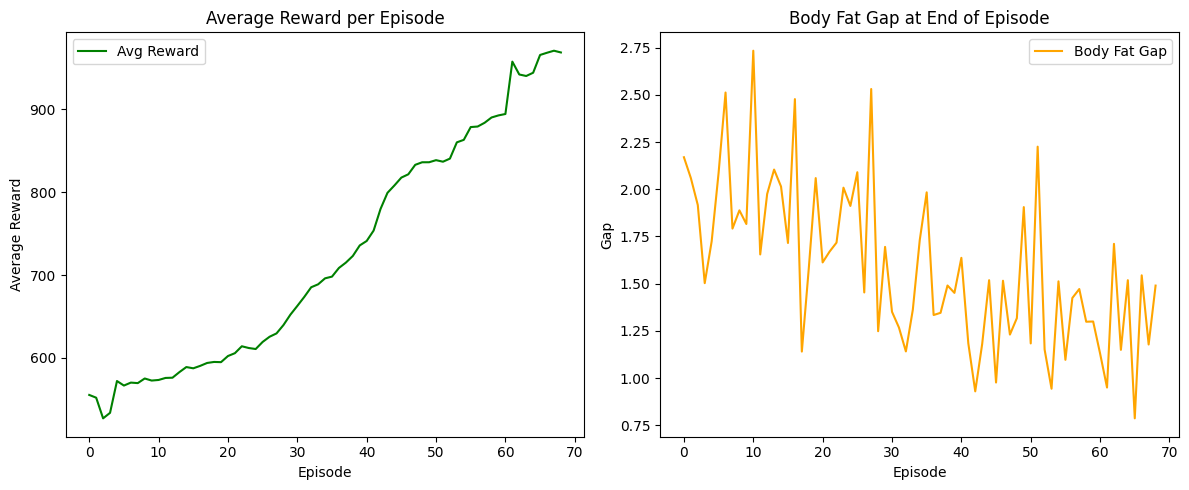

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 1. Average reward per episode
axs[0].plot(callback.avg_rewards, label="Avg Reward", color="green")
axs[0].set_title("Average Reward per Episode")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Average Reward")
axs[0].legend()

# 2. Body fat gap at end of episode
axs[1].plot(callback.body_fat_gaps, label="Body Fat Gap", color="orange")
axs[1].set_title("Body Fat Gap at End of Episode")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Gap")
axs[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
def smooth(data, window=10):
  if len(data) < window:
      return data
  return np.convolve(data, np.ones(window)/window, mode="valid")
def plot_metrics(callback, action_map=None):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    action_counts = collections.Counter(callback.actions)
    axs[0].bar(action_counts.keys(), action_counts.values(), color="skyblue")
    if action_map:
        axs[0].set_xticks(range(len(action_map)))
        axs[0].set_xticklabels(list(action_map.values()), rotation=45, ha="right")
    else:
        axs[0].set_xticks(list(action_counts.keys()))
        axs[0].set_xticklabels(list(action_counts.keys()))
    axs[0].set_title("Action Distribution")
    axs[0].set_ylabel("Frequency")

    if len(callback.step_rewards) > 0:
        rewards = np.array(callback.step_rewards)
        window = min(90000, len(rewards))
        if len(rewards) >= window:
            moving_avg = smooth(rewards, window)
            axs[1].plot(moving_avg, color="purple")
            axs[1].set_title(f"Moving Average Reward (window={window})")
            axs[1].set_xlabel("Step")
            axs[1].set_ylabel("Reward")

    plt.tight_layout()
    plt.show()


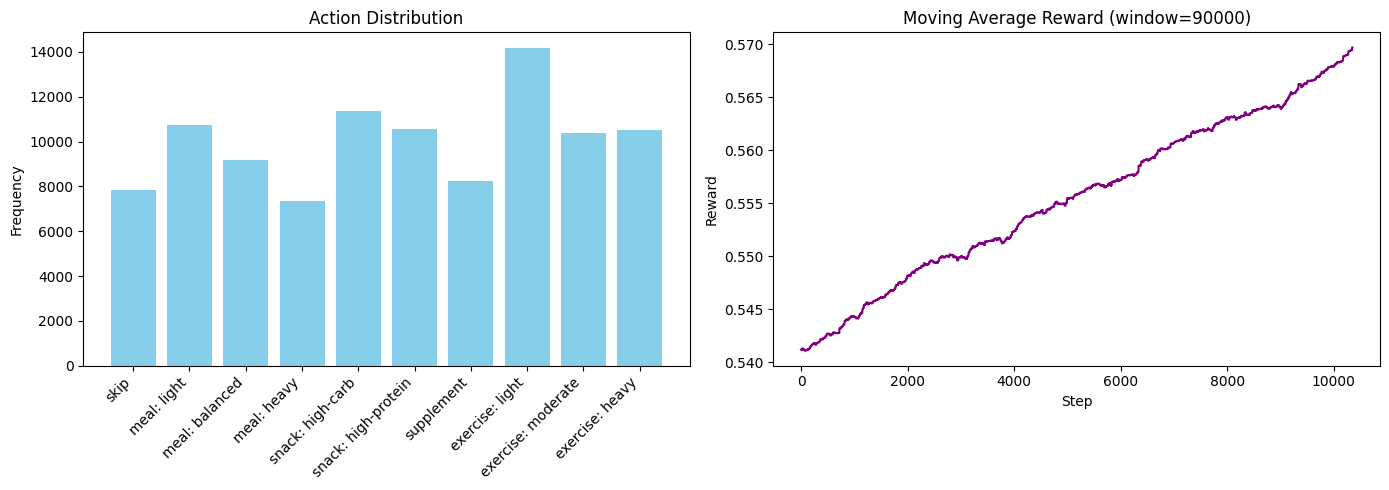

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plot_metrics(callback, action_map)

Show the Daily Action,Reward

In [ ]:
import matplotlib.pyplot as plt
import collections # Import collections for Counter

action_map = {
    0: "skip",
    1: "meal: light",
    2: "meal: balanced",
    3: "meal: heavy",
    4: "snack: high-carb",
    5: "snack: high-protein",
    6: "supplement",
    7: "exercise: light",
    8: "exercise: moderate",
    9: "exercise: heavy",
}

print("\n--- Evaluating the trained agent ---")
eval_env = gym.make(
    env_id,
    gender=1,
    age=25,
    height=175.0,
    weight=70.0,
    target_body_fat=15.0,
    days_per_episode=30,
    workloads=1.5,
    sleep_duration=8
)

days_to_show = 30
hours_per_day = 24
all_records = []

obs, _ = eval_env.reset()

for day in range(days_to_show):
    print(f"\n=== Day {day} ===")
    for hour in range(hours_per_day):
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, terminated, truncated, info = eval_env.step(action.item())
        done = terminated or truncated

        time_str = f"{hour:02d}:00"

        current_activity = eval_env.unwrapped.scheduler[hour]
        if current_activity in ["sleep", "work"]:
            label = current_activity
        else:
            label = action_map.get(int(action), f"action {int(action)}")

        body_fat = eval_env.unwrapped.state.get("current_body_fat", np.nan)


        print(f"  Reward: {reward:.2f}")
        print(f"  Body Fat: {body_fat:.2f}")
        print(f"{time_str} → {label}")

        all_records.append((day, hour, label, float(reward)))

        if done:
            print(f"Episode finished early at Day {day}, Hour {hour}")
            break
    if done:
        break





--- Evaluating the trained agent ---

=== Day 0 ===
Hour 0, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 58.80
  Reward: 1.50
  Body Fat: 16.98
00:00 → sleep
Hour 1, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 117.60
  Reward: -0.50
  Body Fat: 16.98
01:00 → sleep
Hour 2, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 176.40
  Reward: 0.20
  Body Fat: 16.98
02:00 → sleep
Hour 3, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 235.20
  Reward: 0.20
  Body Fat: 16.98
03:00 → sleep
Hour 4, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 294.00
  Reward: 0.20
  Body Fat: 16.98
04:00 → sleep
Hour 5, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 352.80
  Reward: 0.20
  Body Fat: 16.98
05:00 → sleep
Hour 6, Day 0
  Daily Calories Intake: 200.00
  Daily Calories Burned: 352.80
  Reward: 0.50
  Body Fat: 16.98
06:00 → snack: high-protein
Hour 7, Day 0
  Daily Calories Intake: 400.00
  Daily Calories Burned:

In [ ]:
import matplotlib.pyplot as plt

COLOR_MAP = {
    "sleep": "blue",
    "work": "gray",
    "skip": "lightgray",
    "meal: light": "orange",
    "meal: balanced": "gold",
    "meal: heavy": "red",
    "snack: high-carb": "pink",
    "snack: high-protein": "purple",
    "supplement": "brown",
    "exercise: light": "lightgreen",
    "exercise: moderate": "lime",
    "exercise: heavy": "darkgreen",
}

def plot_gantt(all_records, days_to_show, hours_per_day=24, title="Agent Schedule (Gantt Chart)"):

    row_height = 1.2
    row_gap = 0.5

    fig, ax = plt.subplots(figsize=(24, 1.5 * days_to_show))

    for day, hour, label, reward in all_records:
        y_pos = day * (row_height + row_gap)
        ax.broken_barh(
            [(hour, 1)], (y_pos, row_height),
            facecolors=COLOR_MAP.get(label, "lightgray"),
            edgecolors="black"
        )
        ax.text(hour + 0.5, y_pos + row_height/2, label,
                ha="center", va="center", fontsize=9, rotation=90)

    ax.set_xlim(0, hours_per_day)
    ax.set_ylim(-0.5, days_to_show * (row_height + row_gap))
    ax.set_xticks(range(0, hours_per_day + 1, 2))
    ax.set_yticks([i*(row_height+row_gap)+row_height/2 for i in range(days_to_show)])
    ax.set_yticklabels([f"Day {i}" for i in range(days_to_show)])
    ax.set_ylabel("Day")
    ax.set_xlabel("Hour of Day")
    ax.set_title(title, fontsize=16)

    handles = [plt.Rectangle((0,0),1,1, color=c) for c in COLOR_MAP.values()]
    ax.legend(handles, COLOR_MAP.keys(), bbox_to_anchor=(1.05, 1),
              loc='upper left', fontsize=10, title="Activities")

    plt.tight_layout()
    plt.show()


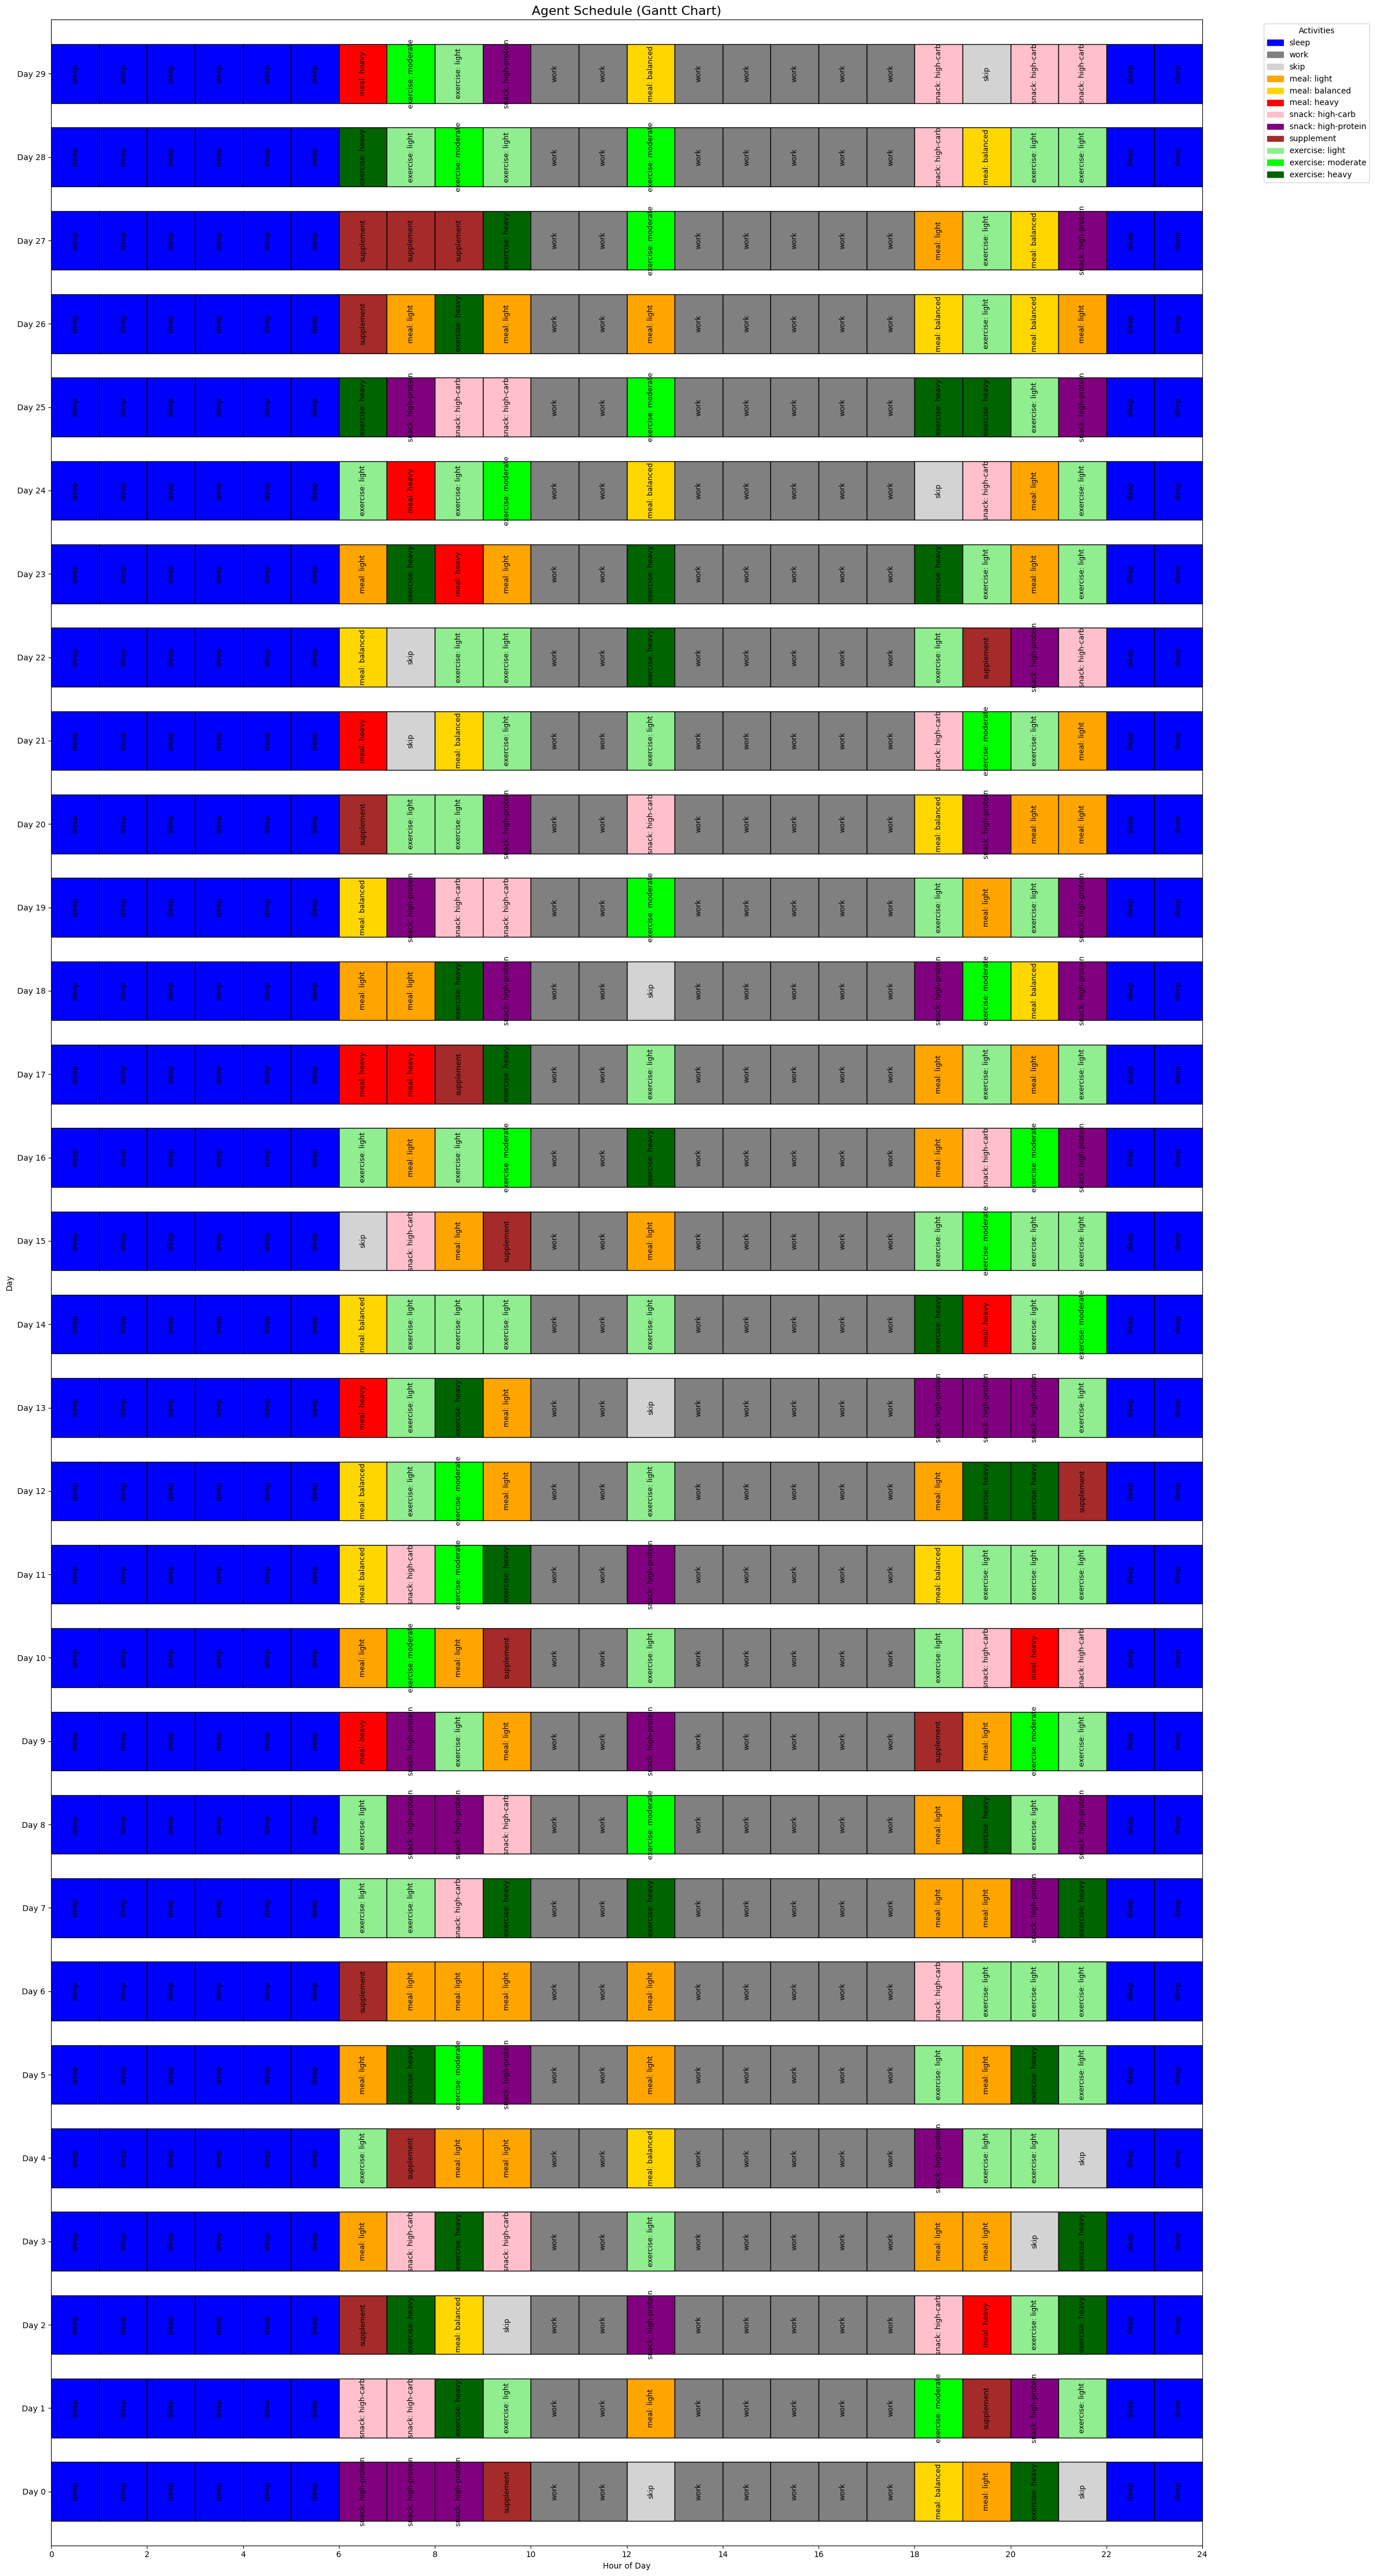

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plot_gantt(all_records, days_to_show)


Exploration Strategy Evaluation

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Streaming output truncated to the last 5000 lines.
  Daily Calories Intake: 1700.00
  Daily Calories Burned: 2164.36
Hour 22, Day 31
  Daily Calories Intake: 1700.00
  Daily Calories Burned: 2222.96
Hour 23, Day 31
  Daily Calories Intake: 1700.00
  Daily Calories Burned: 2281.55
Hour 0, Day 32
  Daily Calories Intake: 0.00
  Daily Calories Burned: 58.53
Hour 1, Day 32
  Daily Calories Intake: 0.00
  Daily Calories Burned: 117.06
Hour 2, Day 32
  Daily Calories Intake: 0.00
  Daily Calories Burned: 175.60
Hour 3, Day 32
  Daily Calories Intake: 0.00
  Daily Calories Burned: 234.13
Hour 4, Day 32
  Daily Calories Intake: 0.00
  Daily Calories Burned: 292.66
Hour 5, Day 32
  Daily Calories Intake: 0.00
  Daily Calories Burned: 351.19
Hour 6, Day 32
  Daily Calories Intake: 250.00
  Daily Calories Burned: 351.19
Hour 7, Day 32
  Daily Calories Intake: 650.00
  Daily Calories Burned: 351.19
Hour 8, Day 32
  Daily Calories Intake: 1050.00
  Daily Calories Burned: 351.19
Hour 9, Day 32
  Dai

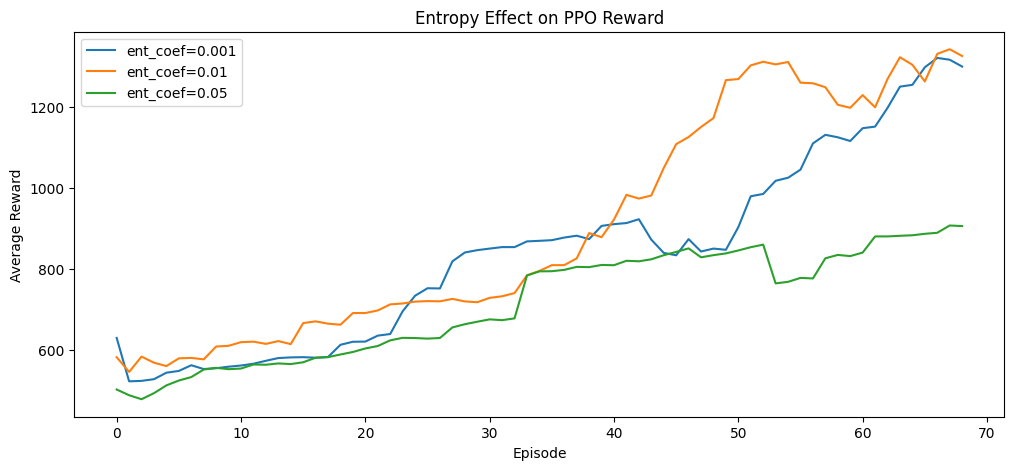

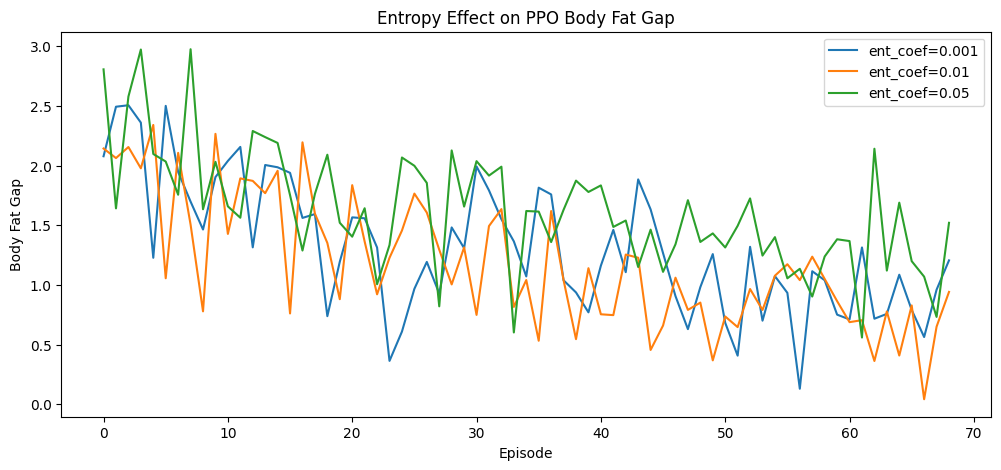

In [ ]:
ent_coefs = [0.001, 0.01, 0.05]
histories = {}

for coef in ent_coefs:
    vec_env = make_vec_env(env_id, n_envs=1, seed=0, env_kwargs={
        "gender": 1, "age": 25, "height": 175.0, "weight": 70.0,
        "target_body_fat": 15.0, "days_per_episode": 60,
        "workloads": 1.5, "sleep_duration": 8
    })

    callback = MetricsCallback()
    model = PPO(
        "MultiInputPolicy", vec_env,
        learning_rate=2.7e-5,
        n_steps=2048,
        batch_size=128,
        n_epochs=5,
        gamma=0.984,
        gae_lambda=0.83,
        ent_coef=coef,
        vf_coef=0.83,
        clip_range=0.24,
        verbose=0
    )

    model.learn(total_timesteps=100_000, callback=callback)
    histories[coef] = callback
    vec_env.close()

plt.figure(figsize=(12,5))
for coef, cb in histories.items():
    plt.plot(cb.avg_rewards, label=f"ent_coef={coef}")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Entropy Effect on PPO Reward")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
for coef, cb in histories.items():
    plt.plot(cb.body_fat_gaps, label=f"ent_coef={coef}")
plt.xlabel("Episode")
plt.ylabel("Body Fat Gap")
plt.title("Entropy Effect on PPO Body Fat Gap")
plt.legend()
plt.show()


In [ ]:
import seaborn as sns

def plot_action_distribution(callback, action_map=None, bins=10):
    episodes = len(callback.episode_rewards)
    actions = np.array(callback.actions)

    split_points = np.linspace(0, len(actions), bins+1, dtype=int)

    fig, axs = plt.subplots(2, bins//2, figsize=(18,8))
    axs = axs.flatten()

    for i in range(bins):
        start, end = split_points[i], split_points[i+1]
        part = actions[start:end]

        sns.countplot(x=part, ax=axs[i], palette="viridis")
        axs[i].set_title(f"Episodes {i*(episodes//bins)}-{(i+1)*(episodes//bins)}")
        if action_map:
            axs[i].set_xticklabels(action_map.values(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/tmp/ipython-input-3297125917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=part, ax=axs[i], palette="viridis")
/tmp/ipython-input-3297125917.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(action_map.values(), rotation=45, ha="right")
/tmp/ipython-input-3297125917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=part, ax=axs[i], palette="viridis")
/tmp/ipython-input-3297125917.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(action_map.values(), rotat

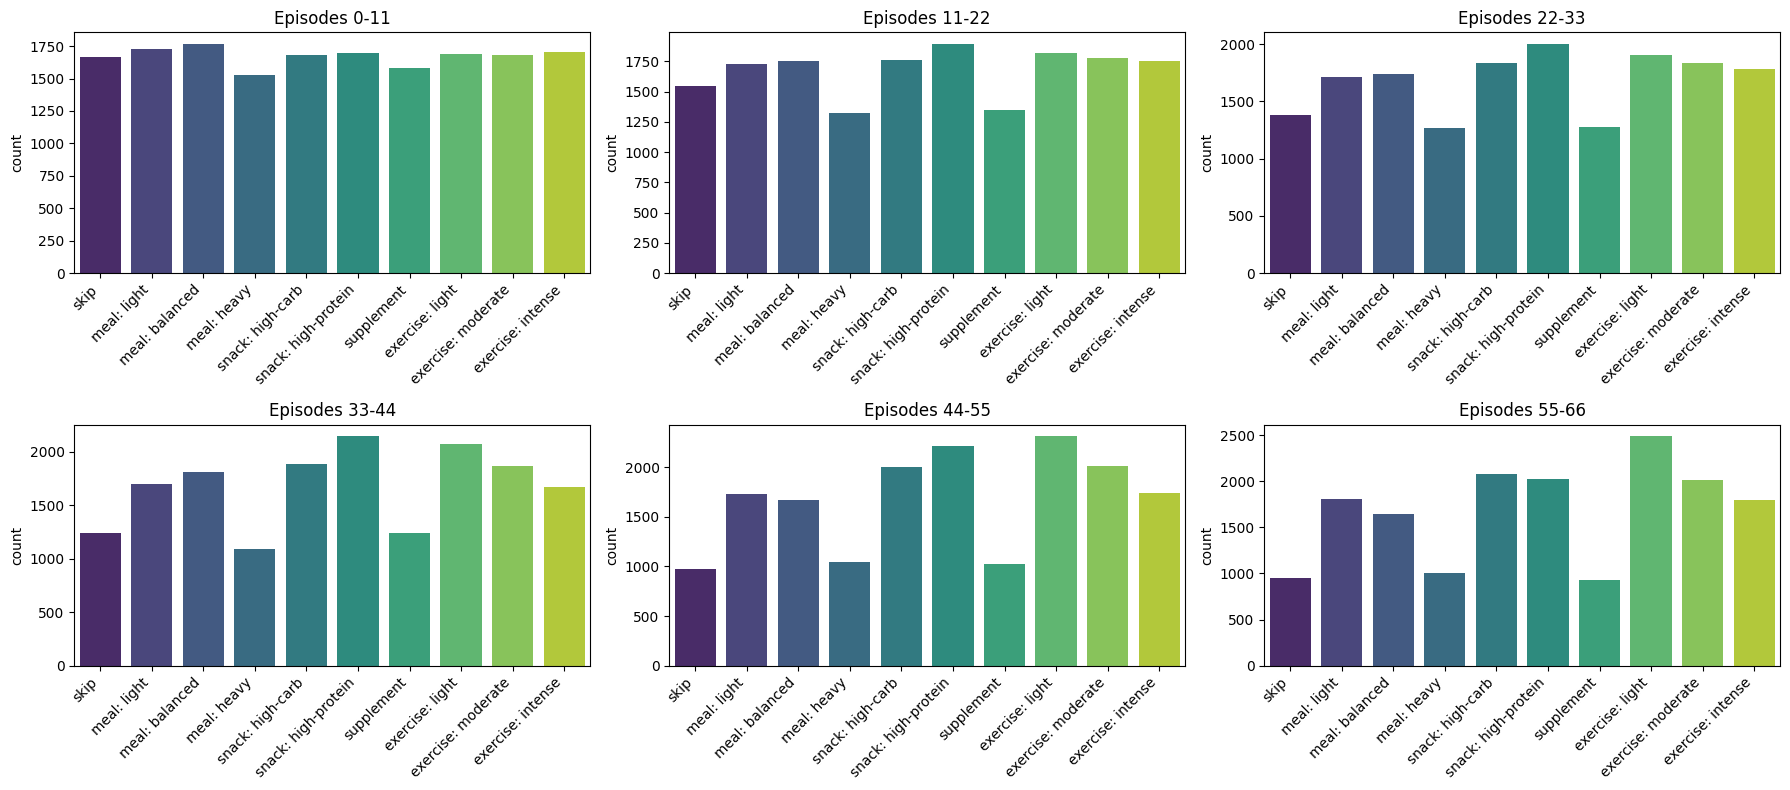

In [ ]:
plot_action_distribution(callback, action_map, bins=6)


Generalization

In [ ]:
def evaluate_generalization(model, env_params_list, episodes=10):
    results = {}

    for i, params in enumerate(env_params_list):
        eval_env = make_vec_env(env_id, n_envs=1, env_kwargs=params)
        ep_rewards = []
        ep_gaps = []

        for ep in range(episodes):
            obs = eval_env.reset()
            total_reward = 0
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, rewards, dones, infos = eval_env.step(action)
                total_reward += rewards[0]
                done = dones[0]
            ep_rewards.append(total_reward)
            ep_gaps.append(infos[0].get("body_fat_gap", np.nan))

        results[f"Test {i+1}"] = {
            "params": params,
            "mean_reward": np.mean(ep_rewards),
            "mean_gap": np.mean(ep_gaps)
        }
        eval_env.close()

    return results

test_envs = [
    {"gender":0, "age":60, "height":165.0, "weight":70.0,
     "target_body_fat":22.0, "days_per_episode":60,
     "workloads":1.5, "sleep_duration":8},

    {"gender":0, "age":40, "height":185.0, "weight":60.0,
     "target_body_fat":16.0, "days_per_episode":30,
     "workloads":2.0, "sleep_duration":7},

    {"gender":1, "age":20, "height":172.5, "weight":120.0,
     "target_body_fat":30.0, "days_per_episode":60,
     "workloads":2.0, "sleep_duration":6},

    {"gender":1, "age":30, "height":162.2, "weight":90.0,
     "target_body_fat":28.0, "days_per_episode":30,
     "workloads":1.8, "sleep_duration":8}
]

results = evaluate_generalization(model, test_envs, episodes=10)
for k,v in results.items():
    print(f"{k}: reward={v['mean_reward']:.2f}, gap={v['mean_gap']:.2f}, params={v['params']}")


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Streaming output truncated to the last 5000 lines.
  Daily Calories Burned: 1524.98
Hour 15, Day 20
  Daily Calories Intake: 400.00
  Daily Calories Burned: 1686.45
Hour 16, Day 20
  Daily Calories Intake: 400.00
  Daily Calories Burned: 1847.91
Hour 17, Day 20
  Daily Calories Intake: 400.00
  Daily Calories Burned: 2009.38
Hour 18, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2009.38
Hour 19, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2121.51
Hour 20, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2233.64
Hour 21, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2345.77
Hour 22, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2417.54
Hour 23, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2489.30
Hour 0, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 71.58
Hour 1, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 143.16
Hour 2, Day 21
  Daily Calories In

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_generalization(model, env_params_list, episodes=10):
    results = {}

    for i, params in enumerate(env_params_list):
        eval_env = make_vec_env(env_id, n_envs=1, env_kwargs=params)
        ep_rewards = []
        ep_gaps = []

        for ep in range(episodes):
            obs = eval_env.reset()
            total_reward = 0
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, rewards, dones, infos = eval_env.step(action)
                total_reward += rewards[0]
                done = dones[0]
            ep_rewards.append(total_reward)
            ep_gaps.append(infos[0].get("body_fat_gap", np.nan))

        results[f"Test {i+1}"] = {
            "params": params,
            "mean_reward": np.mean(ep_rewards),
            "mean_gap": np.mean(ep_gaps)
        }
        eval_env.close()

    return results

def plot_generalization(results):
    labels = list(results.keys())
    rewards = [results[k]["mean_reward"] for k in labels]
    gaps = [results[k]["mean_gap"] for k in labels]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(10,6))

    ax1.bar(x - width/2, rewards, width, label="Mean Reward", color="skyblue")
    ax1.set_ylabel("Mean Reward")
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.set_title("Generalization Performance Across Test Environments")

    ax2 = ax1.twinx()
    ax2.bar(x + width/2, gaps, width, label="Mean Body Fat Gap", color="orange")
    ax2.set_ylabel("Mean Body Fat Gap")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.show()


Streaming output truncated to the last 5000 lines.
  Daily Calories Intake: 400.00
  Daily Calories Burned: 1363.51
Hour 14, Day 20
  Daily Calories Intake: 400.00
  Daily Calories Burned: 1524.98
Hour 15, Day 20
  Daily Calories Intake: 400.00
  Daily Calories Burned: 1686.45
Hour 16, Day 20
  Daily Calories Intake: 400.00
  Daily Calories Burned: 1847.91
Hour 17, Day 20
  Daily Calories Intake: 400.00
  Daily Calories Burned: 2009.38
Hour 18, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2009.38
Hour 19, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2121.51
Hour 20, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2233.64
Hour 21, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2345.77
Hour 22, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2417.54
Hour 23, Day 20
  Daily Calories Intake: 800.00
  Daily Calories Burned: 2489.30
Hour 0, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 71.5

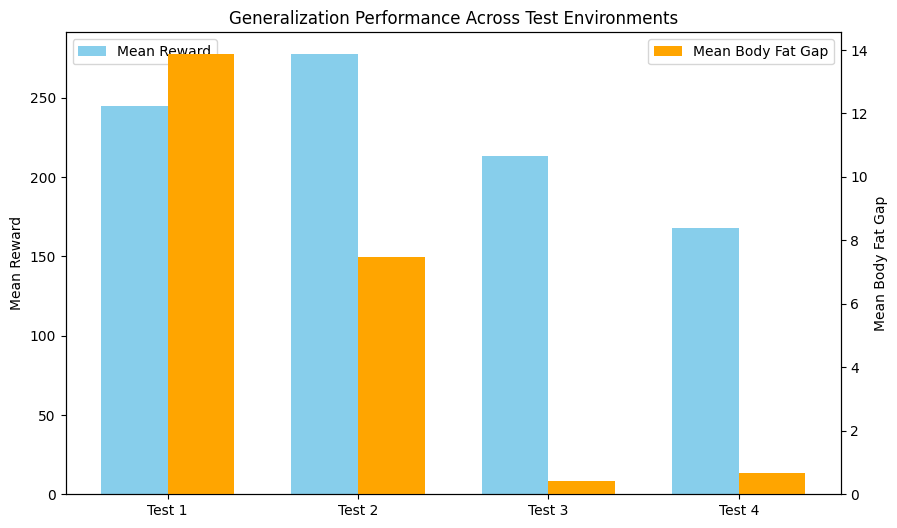

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
results = evaluate_generalization(model, test_envs, episodes=10)
plot_generalization(results)
